In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/smart-water-leak-detection-dataset/location_aware_gis_leakage_dataset.csv


Episode 1/25 - Reward: -16370
Episode 2/25 - Reward: -3038
Episode 3/25 - Reward: 6234
Episode 4/25 - Reward: 12778
Episode 5/25 - Reward: 18050
Episode 6/25 - Reward: 18538
Episode 7/25 - Reward: 22262
Episode 8/25 - Reward: 22742
Episode 9/25 - Reward: 23530
Episode 10/25 - Reward: 24086
Episode 11/25 - Reward: 24550
Episode 12/25 - Reward: 23526
Episode 13/25 - Reward: 24358
Episode 14/25 - Reward: 24662
Episode 15/25 - Reward: 24442
Episode 16/25 - Reward: 24534
Episode 17/25 - Reward: 24694
Episode 18/25 - Reward: 24406
Episode 19/25 - Reward: 24502
Episode 20/25 - Reward: 24918
Episode 21/25 - Reward: 24030
Episode 22/25 - Reward: 25246
Episode 23/25 - Reward: 25258
Episode 24/25 - Reward: 24946
Episode 25/25 - Reward: 25438

Final Metrics
----------------------------------------
Accuracy  : 92.70%
Precision : 45.83%
Recall    : 67.69%
F1 Score  : 54.66%

Smart Repair Plan
--------------------------------------------------
Total Identified Leaks: 96

Priority 1:
  Location: (25.2

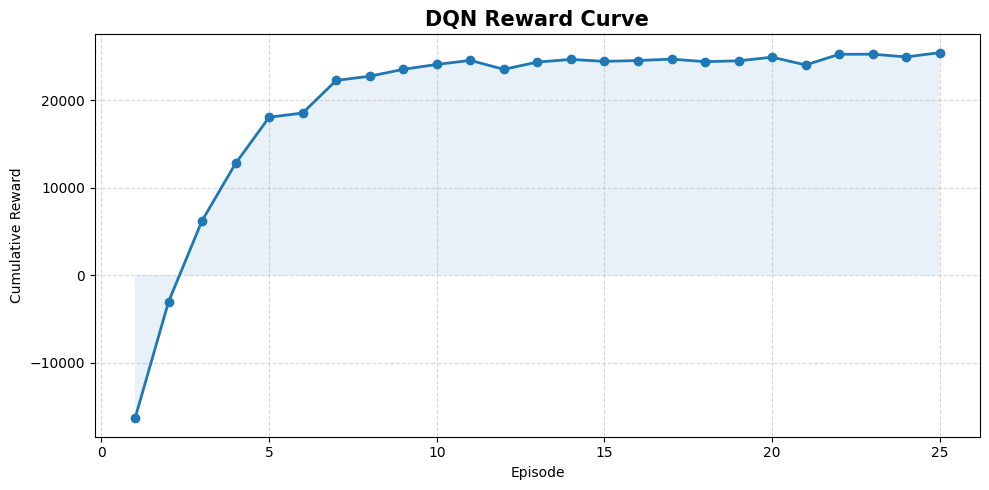

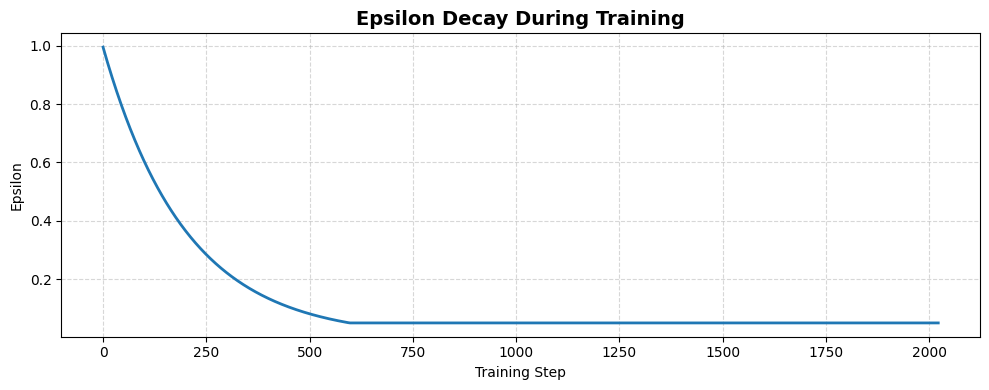

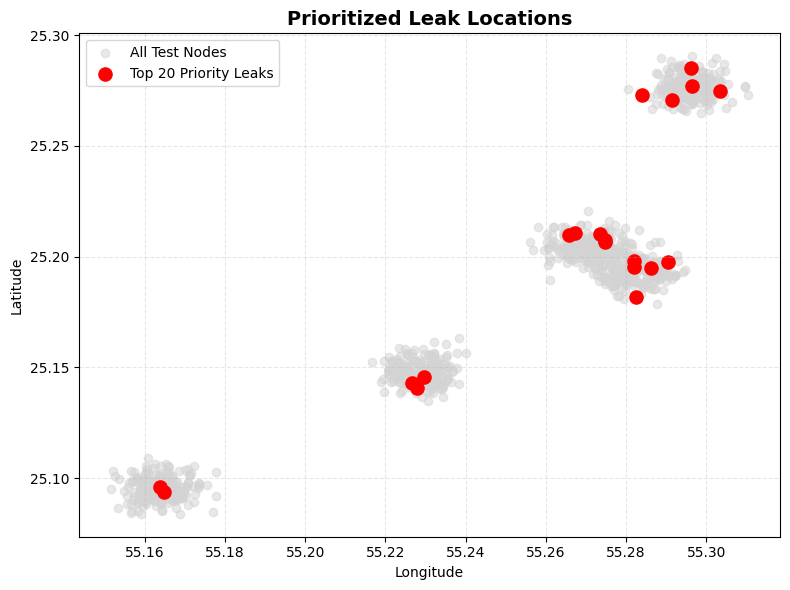


Project Output Summary
----------------------------------------
Metrics File Saved     : results/model_metrics.csv
Repair List Saved      : results/repair_priority_list.csv
Reward Curve Saved     : results/reward_curve.png
Epsilon Decay Saved    : results/epsilon_decay.png
Leak Map Saved         : results/leak_map.png
Highest Severity Score : 1.00
Average Repair Time    : 3.99 hours


In [2]:
# -----------------------------
# 1️⃣ Imports
# -----------------------------
import os
import random
from collections import deque

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# -----------------------------
# 2️⃣ Reproducibility + Setup
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs("results", exist_ok=True)


# -----------------------------
# 3️⃣ Load Data
# -----------------------------
data_path = "/kaggle/input/smart-water-leak-detection-dataset/location_aware_gis_leakage_dataset.csv"
data = pd.read_csv(data_path)

feature_cols = ["Pressure", "Flow_Rate", "Latitude", "Longitude"]
target_col = "Leakage_Flag"

X_raw = data[feature_cols]
y = data[target_col].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)


# -----------------------------
# 4️⃣ DQN Network
# -----------------------------
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)


# -----------------------------
# 5️⃣ DQN Agent
# -----------------------------
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.state_dim = state_dim
        self.action_dim = action_dim

        self.memory = deque(maxlen=5000)
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.995
        self.lr = 0.001
        self.batch_size = 64

        self.model = DQN(state_dim, action_dim).to(device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.loss_fn = nn.MSELoss()

        self.epsilon_history = []

    def act(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)

        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.model(state_tensor)
        return torch.argmax(q_values).item()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return

        batch = random.sample(self.memory, self.batch_size)

        states = torch.FloatTensor(np.array([b[0] for b in batch])).to(device)
        actions = torch.LongTensor([b[1] for b in batch]).unsqueeze(1).to(device)
        rewards = torch.FloatTensor([b[2] for b in batch]).to(device)
        next_states = torch.FloatTensor(np.array([b[3] for b in batch])).to(device)
        dones = torch.FloatTensor([b[4] for b in batch]).to(device)

        current_q = self.model(states).gather(1, actions).squeeze()
        next_q = self.model(next_states).max(1)[0]
        target_q = rewards + self.gamma * next_q * (1 - dones)

        loss = self.loss_fn(current_q, target_q.detach())
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        self.epsilon_history.append(self.epsilon)


# -----------------------------
# 6️⃣ Initialize Agent
# -----------------------------
state_dim = X_train.shape[1]
action_dim = 2   # 0 = no leak, 1 = leak
agent = DQNAgent(state_dim, action_dim)


# -----------------------------
# 7️⃣ Supervised Pretraining
# -----------------------------
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)

pretrain_optimizer = optim.Adam(agent.model.parameters(), lr=0.001)
pretrain_loss_fn = nn.CrossEntropyLoss()

for epoch in range(5):
    pretrain_optimizer.zero_grad()
    outputs = agent.model(X_train_tensor)
    loss = pretrain_loss_fn(outputs, y_train_tensor)
    loss.backward()
    pretrain_optimizer.step()


# -----------------------------
# 8️⃣ RL Training
# -----------------------------
episodes = 25
reward_history = []

for episode in range(episodes):
    episode_reward = 0

    for i in range(len(X_train)):
        state = X_train[i]
        action = agent.act(state)

        # Balanced reward design
        if y_train[i] == 1 and action == 1:
            reward = 15      # correct leak
        elif y_train[i] == 1 and action == 0:
            reward = -25     # missed leak
        elif y_train[i] == 0 and action == 1:
            reward = -20     # false alarm
        else:
            reward = 8       # correct no-leak

        next_state = X_train[i + 1] if i < len(X_train) - 1 else state
        done = 1 if i == len(X_train) - 1 else 0

        agent.remember(state, action, reward, next_state, done)
        episode_reward += reward

        if i % 50 == 0:
            agent.replay()

    agent.replay()
    reward_history.append(episode_reward)
    print(f"Episode {episode + 1}/{episodes} - Reward: {episode_reward}")


# -----------------------------
# 9️⃣ Evaluation
# -----------------------------
predictions = np.array([agent.act(state) for state in X_test])

accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, zero_division=0)
recall = recall_score(y_test, predictions, zero_division=0)
f1 = f1_score(y_test, predictions, zero_division=0)

print("\nFinal Metrics")
print("-" * 40)
print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")


# -----------------------------
# 🔟 Repair Prioritization Support
# -----------------------------
detected_leak_indices = np.where(predictions == 1)[0]
predicted_leaks_df = X_test_raw.iloc[detected_leak_indices].copy()

if len(predicted_leaks_df) > 0:
    predicted_leaks_df["Predicted_Leak"] = 1

    flow_norm = predicted_leaks_df["Flow_Rate"] / predicted_leaks_df["Flow_Rate"].max()
    pressure_norm = predicted_leaks_df["Pressure"] / predicted_leaks_df["Pressure"].max()

    # High flow + low pressure => higher severity
    predicted_leaks_df["Severity_Score"] = flow_norm + (1 - pressure_norm)
    predicted_leaks_df["Severity_Score"] = (
        predicted_leaks_df["Severity_Score"] / predicted_leaks_df["Severity_Score"].max()
    ).round(3)

    predicted_leaks_df["Estimated_Repair_Time_Hours"] = (
        1 + predicted_leaks_df["Severity_Score"] * 4
    ).round(2)

    predicted_leaks_df = predicted_leaks_df.sort_values(
        by="Severity_Score", ascending=False
    ).reset_index(drop=True)

    predicted_leaks_df["Priority_Rank"] = predicted_leaks_df.index + 1

    predicted_leaks_df.to_csv("results/repair_priority_list.csv", index=False)

    print("\nSmart Repair Plan")
    print("-" * 50)
    print(f"Total Identified Leaks: {len(predicted_leaks_df)}\n")

    for _, row in predicted_leaks_df.head(5).iterrows():
        print(f"Priority {int(row['Priority_Rank'])}:")
        print(f"  Location: ({row['Latitude']:.5f}, {row['Longitude']:.5f})")
        print(f"  Severity Score: {row['Severity_Score']:.2f}")
        print(f"  Estimated Repair Time: {row['Estimated_Repair_Time_Hours']:.1f} hours")
        print("  Action: Repair first\n")

    print("Remaining identified leaks should be handled according to the priority ranking.")

else:
    print("\nNo leaks identified in the test set.")
    predicted_leaks_df = pd.DataFrame()


# -----------------------------
# 1️⃣1️⃣ Save Metrics
# -----------------------------
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
})
metrics_df.to_csv("results/model_metrics.csv", index=False)


# -----------------------------
# 1️⃣2️⃣ Save Useful Visual Outputs
# -----------------------------
# Reward Curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(reward_history) + 1), reward_history, marker="o", linewidth=2)
plt.fill_between(range(1, len(reward_history) + 1), reward_history, alpha=0.1)
plt.title("DQN Reward Curve", fontsize=15, fontweight="bold")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("results/reward_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# Epsilon Decay
plt.figure(figsize=(10, 4))
plt.plot(agent.epsilon_history, linewidth=2)
plt.title("Epsilon Decay During Training", fontsize=14, fontweight="bold")
plt.xlabel("Training Step")
plt.ylabel("Epsilon")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("results/epsilon_decay.png", dpi=300, bbox_inches="tight")
plt.show()

# Leak Distribution Map (only top-priority leaks)
top_k = 20
top_priority_leaks = predicted_leaks_df.head(top_k) if len(predicted_leaks_df) > 0 else pd.DataFrame()

plt.figure(figsize=(8, 6))
plt.scatter(
    X_test_raw["Longitude"],
    X_test_raw["Latitude"],
    color="lightgray",
    alpha=0.5,
    label="All Test Nodes"
)

if len(top_priority_leaks) > 0:
    plt.scatter(
        top_priority_leaks["Longitude"],
        top_priority_leaks["Latitude"],
        color="red",
        s=90,
        label=f"Top {top_k} Priority Leaks"
    )

plt.title("Prioritized Leak Locations", fontsize=14, fontweight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("results/leak_map.png", dpi=300, bbox_inches="tight")
plt.show()


# -----------------------------
# 1️⃣3️⃣ Final Summary
# -----------------------------
print("\nProject Output Summary")
print("-" * 40)
print(f"Metrics File Saved     : results/model_metrics.csv")
print(f"Repair List Saved      : results/repair_priority_list.csv")
print(f"Reward Curve Saved     : results/reward_curve.png")
print(f"Epsilon Decay Saved    : results/epsilon_decay.png")
print(f"Leak Map Saved         : results/leak_map.png")

if len(predicted_leaks_df) > 0:
    print(f"Highest Severity Score : {predicted_leaks_df['Severity_Score'].max():.2f}")
    print(f"Average Repair Time    : {predicted_leaks_df['Estimated_Repair_Time_Hours'].mean():.2f} hours")

In [3]:
import pandas as pd

# Load and print the metrics file
file_path = '/kaggle/working/results/repair_priority_list.csv'
df = pd.read_csv(file_path)

# Display the first 5 rows
print(df.head())

# Or use display() for a nicer, interactive table in Kaggle
display(df)


    Pressure   Flow_Rate   Latitude  Longitude  Predicted_Leak  \
0  39.129730  122.978180  25.207351  55.274849               1   
1  42.602862  115.819516  25.274775  55.303515               1   
2  46.223306  115.725703  25.197508  55.290393               1   
3  28.232962   85.527464  25.195124  55.281899               1   
4  39.006437  101.504375  25.198093  55.281967               1   

   Severity_Score  Estimated_Repair_Time_Hours  Priority_Rank  
0           1.000                         5.00              1  
1           0.933                         4.73              2  
2           0.901                         4.60              3  
3           0.898                         4.59              4  
4           0.889                         4.56              5  


,Pressure,Flow_Rate,Latitude,Longitude,Predicted_Leak,Severity_Score,Estimated_Repair_Time_Hours,Priority_Rank
0,39.129730,122.978180,25.207351,55.274849,1,1.000,5.00,1
1,42.602862,115.819516,25.274775,55.303515,1,0.933,4.73,2
2,46.223306,115.725703,25.197508,55.290393,1,0.901,4.60,3
3,28.232962,85.527464,25.195124,55.281899,1,0.898,4.59,4
4,39.006437,101.504375,25.198093,55.281967,1,0.889,4.56,5
...,...,...,...,...,...,...,...,...
91,68.794170,69.742266,25.274443,55.297460,1,0.468,2.87,92
92,63.673655,58.957008,25.087181,55.159554,1,0.455,2.82,93
93,80.895387,85.395213,25.140982,55.234234,1,0.446,2.78,94
94,62.032360,42.175928,25.210335,55.267966,1,0.382,2.53,95


In [5]:
print("\nRepair Planning Summary")
print("-" * 40)
print(f"Episodes completed     : {episodes}")
print(f"Initial reward         : {reward_history[0]}")
print(f"Final reward           : {reward_history[-1]}")
print("Reward improvement     : Strong upward convergence")

print("\nLeak Identification Summary")
print("-" * 40)
print(f"Total identified leaks : {len(predicted_leaks_df)}")

if len(predicted_leaks_df) > 0:
    top_leak = predicted_leaks_df.iloc[0]

    print("\nRepair Prioritization Summary")
    print("-" * 40)
    print(f"Top priority location  : ({top_leak['Latitude']:.5f}, {top_leak['Longitude']:.5f})")
    print(f"Highest severity score : {top_leak['Severity_Score']:.2f}")
    print(f"Estimated repair time  : {top_leak['Estimated_Repair_Time_Hours']:.1f} hours")

    print("\nTop 5 Priority Repairs")
    print("-" * 40)
    for _, row in predicted_leaks_df.head(5).iterrows():
        print(
            f"{int(row['Priority_Rank'])}. "
            f"({row['Latitude']:.5f}, {row['Longitude']:.5f}) | "
            f"Severity: {row['Severity_Score']:.2f} | "
            f"Repair Time: {row['Estimated_Repair_Time_Hours']:.1f} hrs"
        )

print("\nSaved Outputs")
print("-" * 40)
print("- model_metrics.csv")
print("- repair_priority_list.csv")
print("- reward_curve.png")
print("- epsilon_decay.png")
print("- leak_map.png")



Repair Planning Summary
----------------------------------------
Episodes completed     : 25
Initial reward         : -16370
Final reward           : 25438
Reward improvement     : Strong upward convergence

Leak Identification Summary
----------------------------------------
Total identified leaks : 96

Repair Prioritization Summary
----------------------------------------
Top priority location  : (25.20735, 55.27485)
Highest severity score : 1.00
Estimated repair time  : 5.0 hours

Top 5 Priority Repairs
----------------------------------------
1. (25.20735, 55.27485) | Severity: 1.00 | Repair Time: 5.0 hrs
2. (25.27478, 55.30352) | Severity: 0.93 | Repair Time: 4.7 hrs
3. (25.19751, 55.29039) | Severity: 0.90 | Repair Time: 4.6 hrs
4. (25.19512, 55.28190) | Severity: 0.90 | Repair Time: 4.6 hrs
5. (25.19809, 55.28197) | Severity: 0.89 | Repair Time: 4.6 hrs

Saved Outputs
----------------------------------------
- model_metrics.csv
- repair_priority_list.csv
- reward_curve.png
- ep